# DEMO MODEL

# Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from keras import optimizers

# Prepare data frame of file names and legibility determinations

In [2]:
#read in csv of signatures as a dataframe
df = pd.read_csv('sigs.csv')

In [3]:
df.head(10)

,File Name,Final Assignment
0,sig001.jpg,Illegible
1,sig002.jpg,Legible
2,sig003.jpg,Legible
3,sig004.jpg,Legible
4,sig005.jpg,Legible
5,sig006.jpg,Legible
6,sig007.jpg,Legible
7,sig008.jpg,Illegible
8,sig009.jpg,Legible
9,sig010.jpg,Legible


# Retrieve files from file names in data frame

In [4]:
def get_file_path(file_name):
  return 'sigs/' + file_name

In [5]:
#replace file name in data frame with entire file path
df['File Name'] = df['File Name'].apply(get_file_path)

In [6]:
df.head()

,File Name,Final Assignment
0,sigs/sig001.jpg,Illegible
1,sigs/sig002.jpg,Legible
2,sigs/sig003.jpg,Legible
3,sigs/sig004.jpg,Legible
4,sigs/sig005.jpg,Legible


In [7]:
#renamed second column for clarity in code
df = df.rename(columns={'Final Assignment': 'Legibility'})
df

,File Name,Legibility
0,sigs/sig001.jpg,Illegible
1,sigs/sig002.jpg,Legible
2,sigs/sig003.jpg,Legible
3,sigs/sig004.jpg,Legible
4,sigs/sig005.jpg,Legible
...,...,...
681,sigs/sig682.jpg,Legible
682,sigs/sig683.jpg,Illegible
683,sigs/sig684.jpg,Legible
684,sigs/sig685.jpg,Legible


# Set up model in Keras

In [8]:
#split data frame into five equal sets of data, shuffled
kf = KFold(n_splits=5, shuffle=True)

In [9]:
#normalize pixesl for network efficiency
datagen = ImageDataGenerator(rescale=1./225)

In [10]:
#set dimensions to resize images
IMAGE_HEIGHT = 140
IMAGE_WIDTH = 205
BATCH_SIZE = 686

In [11]:
#creates an array of file names
X = np.array(df['File Name'])

In [12]:
#creates an empty array to store accuracy ratings
accuracy = []

In [13]:
#Class list for model
labels = ['Illegible', 'Legible']

In [14]:
legible_sigs = np.count_nonzero(df['Legibility'] == 'Legible')
legible_sigs

276

In [15]:
illegible_sigs = 686 - legible_sigs
illegible_sigs

410

In [16]:
class_weights = {'Legible': 410, 'Illegible': 276}

Found 548 validated image filenames belonging to 2 classes.
Found 138 validated image filenames belonging to 2 classes.


C:\Users\alex\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 138, 203, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 69, 101, 16)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 67, 99, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 33, 49, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25872)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         827,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 830,737 (3.17 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 138, 203, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 69, 101, 16)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 67, 99, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 33, 49, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 25872)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │         827,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 830,737 (3.17 MB)

 Trainable params: 830,737 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4517 - loss: 0.7430 - val_accuracy: 0.6788 - val_loss: 2.9451
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5774 - loss: 3.9004 - val_accuracy: 0.6788 - val_loss: 1.3623
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5774 - loss: 1.8075 - val_accuracy: 0.6788 - val_loss: 0.6914
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5574 - loss: 0.6920 - val_accuracy: 0.3212 - val_loss: 0.6933
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4226 - loss: 0.6932 - val_accuracy: 0.3212 - val_loss: 0.6933
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4226 - loss: 0.6932 - val_accuracy: 0.3212 - val_loss: 0.7346
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4226 - loss: 0.7163 - val_accuracy: 0.3212 - val_loss: 0.6934
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4226 - loss: 0.6932 - val_accuracy: 0.3285 - val_loss: 0.6934
Epoch 9/15
1/1 ━

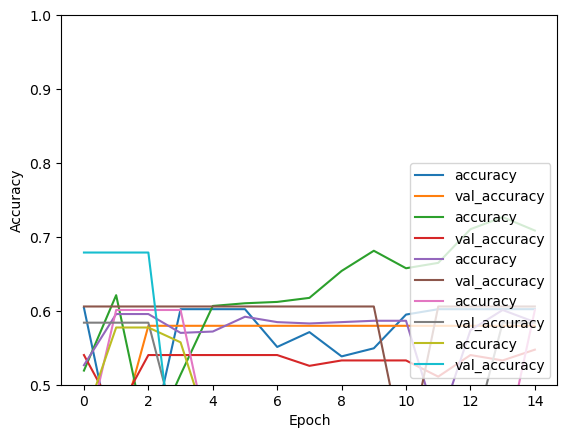

In [17]:
#for loop used for cross validation. iterates through the different sets of data split by the Kfold function
for train_index, test_index in kf.split(X):
    #initial setup of data  
    train_data = X[train_index]
    test_data = X[test_index]
    
    #sets up dataframes based on indexing
    train_dataframe = df.loc[df['File Name'].isin(list(train_data))]
    validation_dataframe = df.loc[df['File Name'].isin(list(test_data))]
    
    #training data
    train_generator = datagen.flow_from_dataframe(
        dataframe=train_dataframe,
        x_col = 'File Name',
        y_col = 'Legibility',
        batch_size = BATCH_SIZE,
        class_mode = 'binary',
        classes = labels,
        target_size = (IMAGE_HEIGHT, IMAGE_WIDTH)
    )

    #validation data
    test_generator = datagen.flow_from_dataframe(
        dataframe=validation_dataframe,
        x_col = 'File Name',
        y_col = 'Legibility',
        batch_size = BATCH_SIZE,
        class_mode = 'binary',
        classes = labels,
        target_size = (IMAGE_HEIGHT, IMAGE_WIDTH)
    )
        
    #model setup
    #neurons kept low to avoid overfitting
    #relu chosen as best activation function
    model = Sequential([
        # first convolutional block
        Conv2D(16, (3, 3), activation='relu', input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),
        MaxPooling2D((2, 2)),

        # Second Convolutional Block
        Conv2D(16, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Flatten the results to feed into a dense layer
        Flatten(),

        # Fully Connected Layer
        Dense(32, activation='relu'),
        Dropout(0.2), # Helps prevent overfitting

        # Output Layer: 1 neuron with a sigmoid activation for binary classification (0 or 1)
        Dense(1, activation='sigmoid')])

    #learning rate modified to avoid overfitting/underfitting
    optm = optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optm,
              loss='binary_crossentropy',
              metrics=['accuracy'],
    )

    #displays model summary and tests data
    #10 epochs chosen for balance of accuracy/optimization
    model.summary()
    EPOCHS = 15
    history = model.fit(
        train_generator,
        validation_data = test_generator,
        epochs = EPOCHS,
        class_weight = class_weights
    )
        
    #plots each fold's accuracy
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0.5, 1])
    plt.legend(loc='lower right')
    
    #appends accuracy list with result from this fold
    accuracy.append(model.evaluate(test_generator))

In [18]:
#first column: loss, second column: validation accuracy
accuracy

[[0.6807453036308289, 0.5797101259231567],
 [0.7455164194107056, 0.5474452376365662],
 [0.6648111343383789, 0.6058394312858582],
 [0.6931100487709045, 0.5839415788650513],
 [0.6931555271148682, 0.32116788625717163]]

In [19]:
print("Average accuracy rating is:")
print(round(np.mean([accuracy[0][1], accuracy[1][1], accuracy[2][1], accuracy[3][1], accuracy[4][1]]), 4))

Average accuracy rating is:
0.5276
